Regularization is the technique to reduce overfitting in regression. Overfitting is the condition where a model performs exceptionally well on the training data  
Three types of regularization:
1. Ridge (L2)
2. Lasso (L1)
3. Elastic Net 

In case of Overflitting we must decrease the slope of the line to some extent such that it performs well on testing data rather than performing exceptionally well on training data

L = summation(yi - yi hat)^2 is the loss function.. we have to add a term which is lambda(hyperparameter)* m^2 which reduces the slope of the function
whose value ranges from 0-infinity 
Since, we use squaring of slope to reduce the variance lambda (m1^2 + m2^2 + m3^2 + mn^2)
So, it is known as L2 norm... so, it is called L2 regularization...

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
# print(data.DESCR)
df =pd.DataFrame(data.data , columns= data.feature_names)
df['target'] = data.target
print (df)

          age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  target  
0   -0.002592  0.019907 -0.0176

In [12]:
X = data.data
y = data.target

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2 , random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [15]:
lr.fit(x_train , y_train)
y_pred = lr.predict(x_test)

In [16]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2 score: ",r2_score(y_test, y_pred))
print("MSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 score:  0.4526027629719197
MSE:  53.85344583676592


In [17]:
from sklearn.linear_model import Ridge

R = Ridge(alpha = 0.001) #alpha is the hyperparamter lambda of the ridge regression which is multiplied with the square of mean

In [18]:
R.fit(x_train, y_train)
y_pred1 = R.predict(x_test)

In [23]:
print("R2 score: ",r2_score(y_test, y_pred1))
print("MSE: ", np.sqrt(mean_squared_error(y_test, y_pred1)))
print(f"Intercept of the line is: {R.intercept_}")
print(f"Slope of the line is: {R.coef_}")

R2 score:  0.453428030101933
MSE:  53.812835253363176
Intercept of the line is: 151.3419805679864
Slope of the line is: [  38.48350519 -241.35179512  543.83517889  346.78283074 -827.70199462
  437.17374869  116.94975277  260.75926436  696.1292235    49.7434469 ]


In [20]:
m = 100
x1 = 5 * np.random.rand(m,1) - 2 #rand generates 100 different random numbers based on the range.. In this case, it ranges between 0 and 1 
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m,1) # randn generates normal data between -1 and 1 such that every x1 has a x2 and x2 is a polynomial regression model... such that it has 2nd power of x1

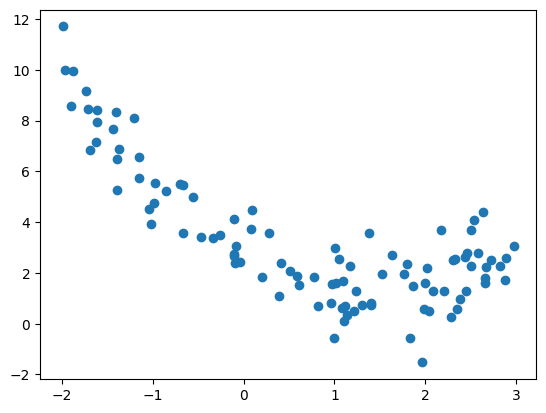

In [21]:
plt.scatter(x1,x2)
plt.show()

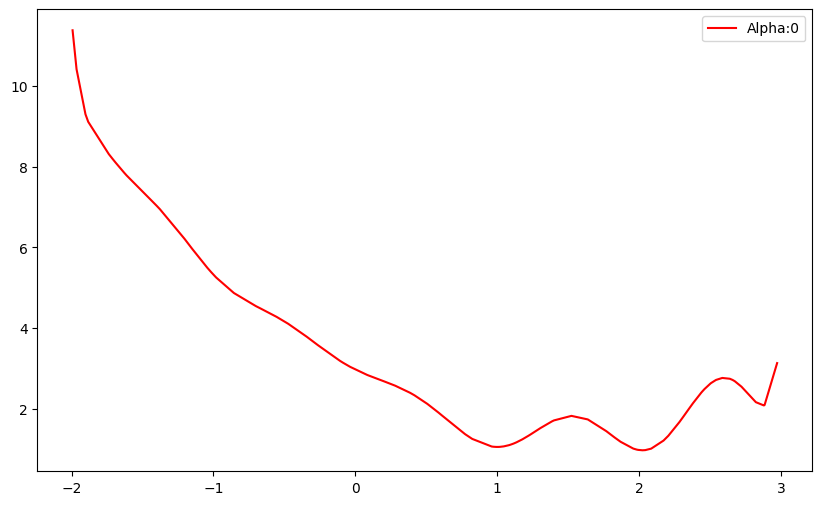

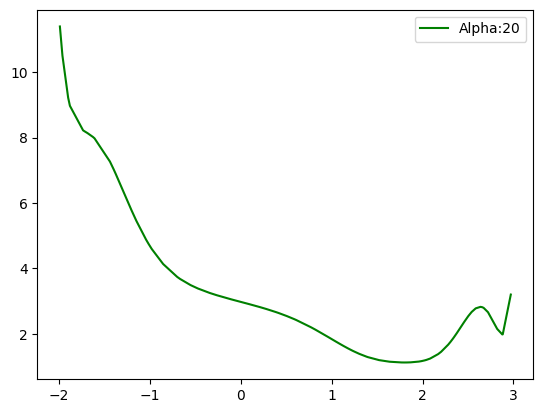

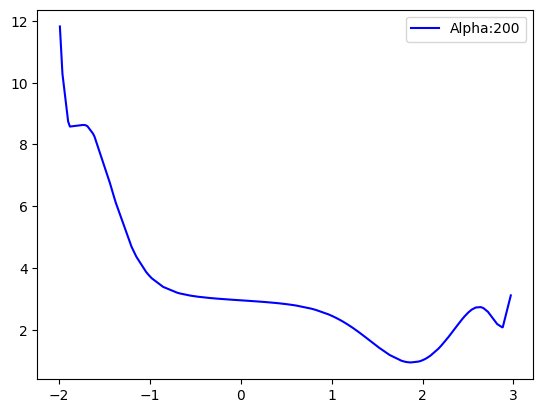

'\nfrom sklearn.preprocessing import PolynomialFeatures\nfrom sklearn.linear_model import Ridge\n\ndef get_preds_ridge(x1, x2, alpha):\n    # Step 1: Create polynomial features\n    poly = PolynomialFeatures(degree=16)\n    X_poly = poly.fit_transform(x1)\n\n    # Step 2: Train Ridge regression on transformed data\n    ridge = Ridge(alpha=alpha)\n    ridge.fit(X_poly, x2)\n\n    # Step 3: Predict (same transformation must be applied)\n    preds = ridge.predict(X_poly)\n\n    return preds\n    '

In [22]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([('poly_feats', PolynomialFeatures(degree = 16)),
                      ('ridge', Ridge(alpha = alpha))])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0,20,200]
cs = ['r','g','b']

plt.figure(figsize=(10,6))
# plt.plot(x1,x2,"b+", label= "Datapoints")

for alpha, c in zip(alphas,cs): #zip() combines two (or more) lists into pairs element by element.
    preds = get_preds_ridge(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[:,0])], c, label = 'Alpha:{}'.format(alpha)) #argsort returns the list of indices of the x1 and according to that y is also sorted making the same pairs as x before sort
    plt.legend()
    plt.show()

'''Here 'Alpha:{}' is a string template with a placeholder {}.
.format(alpha) replaces {} with the current value of alpha. '''

'''
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_ridge(x1, x2, alpha):
    # Step 1: Create polynomial features
    poly = PolynomialFeatures(degree=16)
    X_poly = poly.fit_transform(x1)

    # Step 2: Train Ridge regression on transformed data
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_poly, x2)

    # Step 3: Predict (same transformation must be applied)
    preds = ridge.predict(X_poly)

    return preds
    '''
